In [1]:
import torch
from model.model import EncoderDecoderDAG
from utils.data import TranslateDataset, collate_fn, process_data
from torch.utils.data import DataLoader
from utils.load_tokenizer import load_tokenizer
from torch.optim import Adam
from typing import Tuple
from torch.utils.tensorboard import SummaryWriter
from losses.dag_loss import dag_loss
from utils.fix_probs import fix_probs, masking, acyclic_mask
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
from utils.checkpoint import try_loading, epoch_resume, save_checkpoint

g:\Projects\Visual Studio Code\LMTests\lmtest\lib\site-packages\transformers\utils\hub.py:123: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [2]:
tokenizer, vocab_size = load_tokenizer()

In [3]:
data_dir = "data"
data_file = "processed.pt"

In [4]:
ds = TranslateDataset(data_dir, data_file)

Loading data from data\processed.pt


In [5]:
batch_size = 8

In [6]:
dl = DataLoader(ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

In [7]:
# sample = next(iter(dl))

In [8]:
# ens, zhs = sample

In [9]:
pad_idx = tokenizer.pad_token_id

In [10]:
factor = 4
emb_size = 256
num_heads = 8
max_seq_len = 100
max_vertices = max_seq_len * factor

In [11]:
layers = [(1,1), 1, (1,1)]
out_layers = 1

In [12]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
device

device(type='cuda')

In [14]:
def create_model_fallback_fn() -> Tuple[EncoderDecoderDAG, Adam]:
    model = EncoderDecoderDAG(vocab_size, emb_size, num_heads, max_seq_len, max_vertices, layers, out_layers)
    model.to(device)
    optm = Adam(model.parameters(), lr=1e-3)
    return model, optm
    

In [15]:
checkpoint_dir = "./checkpoints"
checkpoint_name = "naivedag.pt"

In [16]:
model_class = EncoderDecoderDAG
optm_class = Adam

In [17]:
model, optm, losses, log_dir, tokens_seen = try_loading(checkpoint_dir, checkpoint_name, model_class, optm_class, device, create_model_fallback_fn)

Resuming, have seen 244,000 epochs and 89,982,171 tokens
Have 26704968 trainable parameters
Logging to runs/run_at_2023-12-25_15-30-26


In [18]:
writer = SummaryWriter(log_dir=log_dir)

In [19]:
dl_iter = iter(dl)

In [20]:
total_epochs = 274000
remaining, writer_fn = epoch_resume(total_epochs, losses)
save_every = 1500
allow_save = True

Todo:

Mismatch between training and inference time. During inference time, we make transition matrix acyclic but this doesn't happen during training time so the performance is worse than expected.

However, naively making it acyclic while zeroing out transitions to the padding vertices doesn't work as this causes gradient issues, which results in embeddings turning into NaNs. Tets suggest that using small values will also eventually causes NaNs. One possible approach is to punish the model for assigning high values to transitions that will cause cycles.

## Result
Didn't work, the model performed worse (or at least requires more training to reach the same level of performance). I guess we just ignore this and mask out the cycles at inference time instead.

In [21]:
for epoch in (pbar := tqdm(range(remaining))):
    try:
        ens, zhs = next(dl_iter)
    except StopIteration:
        dl_iter = iter(dl)
        ens, zhs = next(dl_iter)
    
    ens, zhs = ens.to(device), zhs.to(device)
    batch_size, l = zhs.shape
    decoder_tokens = torch.arange(0, l * factor).unsqueeze(0).expand(batch_size, -1).to(device)
    target_lens, vertex_lens, _, vertex_mask = process_data(zhs, pad_idx, factor)
    encoder_lens, _, token_mask, _ = process_data(ens, pad_idx, factor)

    optm.zero_grad()
    log_transition_probs, log_emission_probs = model(ens, decoder_tokens, token_mask, vertex_mask)
    loss = dag_loss(zhs, log_transition_probs, log_emission_probs, target_lens, vertex_lens)
    loss.backward()
    optm.step()
    losses.append(loss.item()/batch_size)
    pbar.set_description(f"Loss: {(loss.item()/batch_size):.4f}")
    # if loss is NaN, we emergency exit
    if torch.isnan(loss):
        print(f"EPOCH {epoch} LOSS IS NAN, EMERGENCY EXIT")
        break
    tokens_seen += torch.sum(target_lens).item() + torch.sum(encoder_lens).item()
    writer.add_scalar("loss", loss.item()/batch_size, writer_fn(epoch))
    writer.add_scalar("tokens_seen", tokens_seen, writer_fn(epoch))
    if epoch % save_every == 0 and allow_save:
        save_checkpoint(checkpoint_dir, checkpoint_name, model, losses, optm, tokens_seen, tensorboard_log_dir=log_dir)

  0%|          | 0/30000 [00:00<?, ?it/s]

In [22]:
if allow_save:
    save_checkpoint(checkpoint_dir, checkpoint_name, model, losses, optm, tokens_seen, tensorboard_log_dir=log_dir)

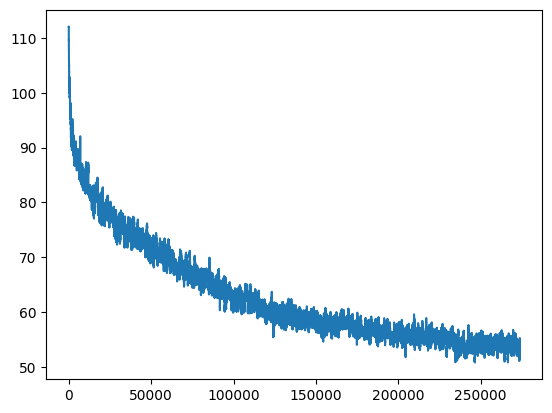

In [23]:
window_size = 300
plt.plot([sum(losses[i:i+window_size])/window_size for i in range(len(losses) - window_size)])